# Project: Business Decision-Making Using Hypothesis Testing

**Brief Description:**
This project aims to help an online store optimize revenue by prioritizing marketing hypotheses, testing them via A/B testing, and analyzing the results to make data-driven decisions.

**Context:**
As part of a joint effort between the analytics and marketing teams, a list of hypotheses was developed to increase store revenue. The project has high business impact as its success directly influences company profitability.

**Project Goal:**
Prioritize hypotheses, test the most promising ones with A/B testing, and analyze the results to support strategic decisions.

**Industry and Data Features:**
E-commerce companies continuously improve user experience and marketing strategies to grow revenue.
Available data includes:
- Hypotheses with scores for Reach, Impact, Confidence, and Effort
- A/B test results with data on orders, revenue, and group assignments

Structure hypothesis.csv:
- `Hypothesis` - a brief description of the hypothesis;
- `Reach` — user coverage on a 10-point scale;
- `Impact` - influence on users on a 10-point scale;
- `Confidence` — confidence in the hypothesis on a 10-point scale;
-`Efforts` - resource costs for testing the hypothesis on a 10-point scale. The higher the Efforts value, the more expensive it is to test the hypothesis.

Structure orders.csv:
- `transactionId` — order identifier;
- `visitorId` — identifier of the user who made the order;
- `date` — the date when the order was made;
- `revenue` — order revenue;
- `group` — the A/B test group into which the order fell.

Structure visitors.csv:
- `date` — date;
- `group` — A/B test group;
- `visitors` — the number of users on the specified date in the specified A/B test group.

**Workflow:**
    
1. **Hypothesis Prioritization:**

- Apply the ICE framework to score and rank hypotheses
- Apply the RICE framework and compare with ICE results
- Explain differences in prioritization outcomes

2. **A/B Test Analysis:**
- Plot cumulative revenue and average order value for both groups
- Visualize relative changes in average order value between groups
- Analyze cumulative orders per visitor and their relative change
- Identify outliers using scatter plots and percentiles (for orders per user and revenue per order)
- Calculate statistical significance of group differences (raw and filtered data)
- Make a final decision: declare a winner, confirm no significant difference, or continue testing

## Hypothesis Prioritization

### Applying the ICE Framework


In [1]:
# Import necessary library
import pandas as pd
import datetime as dt
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the data
hypothesis = pd.read_csv('/Users/arina/Downloads/hypothesis.csv')

To prioritize hypotheses using the ICE framework, we use the following formula:

**ICE = (Impact * Confidence) / Efforts**.

In [3]:
# Calculate ICE score
hypothesis['ICE'] = (hypothesis['Impact'] * hypothesis['Confidence']) / hypothesis['Efforts']

# Sort hypotheses by ICE score in descending order
ice_prioritized = hypothesis[['Hypothesis', 'ICE']].sort_values(by='ICE', ascending=False)

# Display the result
print("Hypothesis prioritization using the ICE framework:")
print(ice_prioritized)

Hypothesis prioritization using the ICE framework:
                                          Hypothesis        ICE
8  Launch a promotion offering a birthday discoun...  16.200000
0  Add two new traffic acquisition channels, whic...  13.333333
7  Add a subscription form to all key pages to bu...  11.200000
6  Display banners with current promotions and sa...   8.000000
2  Add product recommendation blocks to the onlin...   7.000000
1  Launch our own delivery service, which will re...   2.000000
5  Add a customer review page about the store to ...   1.333333
3  Change the category structure, which will impr...   1.125000
4  Change the background color of the homepage to...   1.000000


Hypothesis Prioritization Using the ICE Framework:
- #8 Launch a promotion offering a birthday discount.
- #0 Add two new traffic acquisition channels, which will attract 30% more new users.
- #7 Add a subscription form to all key pages to build a client base for email campaigns.
- #6 Display banners with current promotions and sales on the homepage to increase conversion.

### Apply the RICE Framework for Hypothesis Prioritization

To prioritize hypotheses using the RICE framework, we use the following formula:

**RICE = (Reach * Impact * Confidence) / Efforts**.

In [4]:
# Calculate RICE score
hypothesis['RICE'] = (hypothesis['Reach'] * hypothesis['Impact'] * hypothesis['Confidence']) / hypothesis['Efforts']

# Sort hypotheses by RICE score
rice_prioritized = hypothesis[['Hypothesis', 'RICE']].sort_values(by='RICE', ascending=False)

# Display the result
print("\nHypothesis prioritization using the RICE framework:")
print(rice_prioritized)



Hypothesis prioritization using the RICE framework:
                                          Hypothesis   RICE
7  Add a subscription form to all key pages to bu...  112.0
2  Add product recommendation blocks to the onlin...   56.0
0  Add two new traffic acquisition channels, whic...   40.0
6  Display banners with current promotions and sa...   40.0
8  Launch a promotion offering a birthday discoun...   16.2
3  Change the category structure, which will impr...    9.0
1  Launch our own delivery service, which will re...    4.0
5  Add a customer review page about the store to ...    4.0
4  Change the background color of the homepage to...    3.0


Hypothesis Prioritization Using the RICE Framework:
- #7 Add a subscription form to all key pages to build a client base for email campaigns.
- #2 Add product recommendation blocks to increase the average order value.
- #0 Add two new traffic acquisition channels, which will attract 30% more new users.
- #6 Display banners with current promotions and sales on the homepage to increase conversion.

### How the Prioritization Changed with RICE Compared to ICE

In [5]:
# Get ranks (1 = highest)
hypothesis['ICE_rank'] = hypothesis['ICE'].rank(ascending=False).astype(int)
hypothesis['RICE_rank'] = hypothesis['RICE'].rank(ascending=False).astype(int)

# Sort for convenience
hypothesis_sorted = hypothesis[['Hypothesis', 'ICE', 'ICE_rank', 'RICE', 'RICE_rank']].sort_values(by='ICE_rank')

# Display with highlighting
styled = hypothesis_sorted.style.background_gradient(subset=['ICE_rank', 'RICE_rank'], cmap='viridis_r')
styled

,Hypothesis,ICE,ICE_rank,RICE,RICE_rank
8,Launch a promotion offering a birthday discount to encourage purchases.,16.200000,1,16.200000,5
0,"Add two new traffic acquisition channels, which will allow us to attract 30% more users.",13.333333,2,40.000000,3
7,Add a subscription form to all key pages to build a customer base for email marketing.,11.200000,3,112.000000,1
6,Display banners with current promotions and sales on the homepage to increase conversion.,8.000000,4,40.000000,3
2,Add product recommendation blocks to the online store website to increase conversion rates and average order value.,7.000000,5,56.000000,2
1,"Launch our own delivery service, which will reduce the order delivery time.",2.000000,6,4.000000,7
5,Add a customer review page about the store to increase the number of orders.,1.333333,7,4.000000,7
3,"Change the category structure, which will improve conversion by helping users find products faster.",1.125000,8,9.000000,6
4,Change the background color of the homepage to increase user engagement.,1.000000,9,3.000000,9


When switching from ICE to RICE, the prioritization of hypotheses changed due to the inclusion of the **Reach** factor — the number of users affected by the change.

For example, the hypothesis about adding a **subscription form (#7**) moved to the top in RICE because of its high user reach. In contrast, the **birthday discount hypothesis (#8)** dropped in ranking due to its low reach, even though it had a high ICE score.

## Part. A/B Test Analysis

In [6]:
# Load data
orders = pd.read_csv('/Users/arina/Downloads/orders.csv', sep=',')
visitors = pd.read_csv('/Users/arina/Downloads/visitors.csv', sep=',')

In [7]:
# Check general info
display(orders.info())
display(visitors.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   transactionId  1197 non-null   int64 
 1   visitorId      1197 non-null   int64 
 2   date           1197 non-null   object
 3   revenue        1197 non-null   int64 
 4   group          1197 non-null   object
dtypes: int64(3), object(2)
memory usage: 46.9+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      62 non-null     object
 1   group     62 non-null     object
 2   visitors  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


None

In [8]:
# Convert date columns to datetime format
orders['date'] = pd.to_datetime(orders['date'])
visitors['date'] = pd.to_datetime(visitors['date'])

display(orders.head(5))
display(visitors.head(5))

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B


,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


In [9]:
# Check for missing values in orders
print("Missing values in orders data:")
print(orders.isnull().sum())

# Check for missing values in visitors
print("\nMissing values in visitors data:")
print(visitors.isnull().sum())

Missing values in orders data:
transactionId    0
visitorId        0
date             0
revenue          0
group            0
dtype: int64

Missing values in visitors data:
date        0
group       0
visitors    0
dtype: int64


In [10]:
# Check for duplicates in orders
print("Duplicate entries in orders data:", orders.duplicated().sum())

# Check for duplicates in visitors
print("Duplicate entries in visitors data:", visitors.duplicated().sum())

Duplicate entries in orders data: 0
Duplicate entries in visitors data: 0


In [11]:
# Count users who appear in both groups
users_in_both_groups = orders.groupby('visitorId')['group'].nunique()
users_in_both_groups_count = len(users_in_both_groups[users_in_both_groups > 1])

# Output result
print("Number of users in both groups:", users_in_both_groups_count)

Number of users in both groups: 58


In [12]:
# Filter out users who are in both groups
orders_filtered = orders[~orders['visitorId'].isin(users_in_both_groups[users_in_both_groups > 1].index)]

### Build a graph of cumulative revenue by group. Draw conclusions and assumptions.

In [13]:
# Create a dataframe with unique 'date' and 'group' combinations
dates_groups = orders_filtered[['date','group']].drop_duplicates()

In [14]:
# Aggregate cumulative daily order data
orders_aggregated = dates_groups.apply(
    lambda x: orders_filtered[
        (orders_filtered['date'] <= x['date']) & 
        (orders_filtered['group'] == x['group'])
    ].agg({
        'date': 'max',
        'group': 'max',
        'transactionId': 'nunique',
        'visitorId': 'nunique',
        'revenue': 'sum'
    }),
    axis=1
).sort_values(by=['date','group'])

In [15]:
# Aggregate cumulative daily visitor data
visitors_aggregated = dates_groups.apply(
    lambda x: visitors[
        (visitors['date'] <= x['date']) & 
        (visitors['group'] == x['group'])
    ].agg({
        'date': 'max',
        'group': 'max',
        'visitors': 'sum'
    }),
    axis=1
).sort_values(by=['date','group'])

In [16]:
# Merge and rename columns
cumulative_data = orders_aggregated.merge(visitors_aggregated, on=['date', 'group'])
cumulative_data.columns = ['date', 'group', 'orders', 'buyers', 'revenue', 'visitors']

In [17]:
print(cumulative_data.head(5)) 

        date group  orders  buyers  revenue  visitors
0 2019-08-01     A      23      19   142779       719
1 2019-08-01     B      17      17    59758       713
2 2019-08-02     A      42      36   234381      1338
3 2019-08-02     B      40      39   221801      1294
4 2019-08-03     A      66      60   346854      1845


Now that we have all the necessary cumulative data, let's move on to plotting!

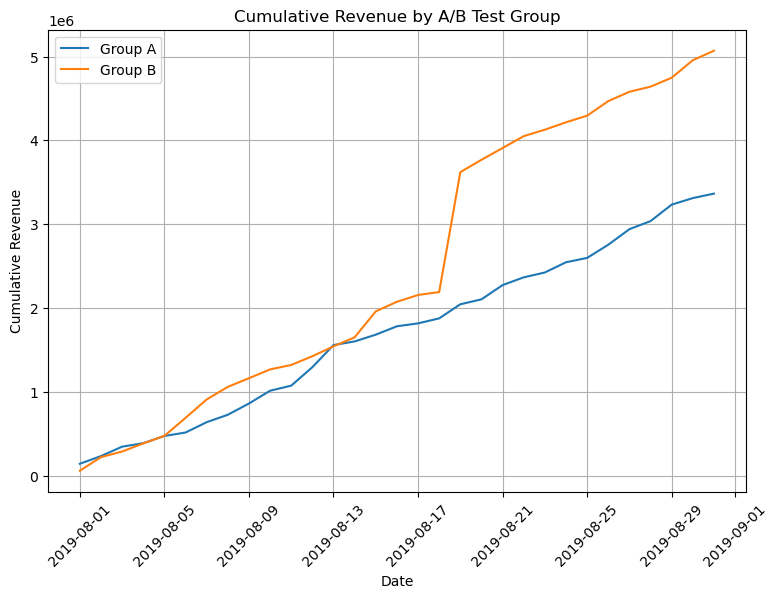

In [18]:
# Split data by group
cumulative_data_A = cumulative_data[cumulative_data['group'] == 'A']
cumulative_data_B = cumulative_data[cumulative_data['group'] == 'B']

# Plot cumulative revenue
plt.figure(figsize=(9, 6))

# Group A
plt.plot(cumulative_data_A['date'], cumulative_data_A['revenue'], label='Group A')

# Group B
plt.plot(cumulative_data_B['date'], cumulative_data_B['revenue'], label='Group B')

plt.title('Cumulative Revenue by A/B Test Group')
plt.xlabel('Date')
plt.ylabel('Cumulative Revenue')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


In [19]:
# Split data by group
cumulative_data_A = cumulative_data[cumulative_data['group'] == 'A']
cumulative_data_B = cumulative_data[cumulative_data['group'] == 'B']

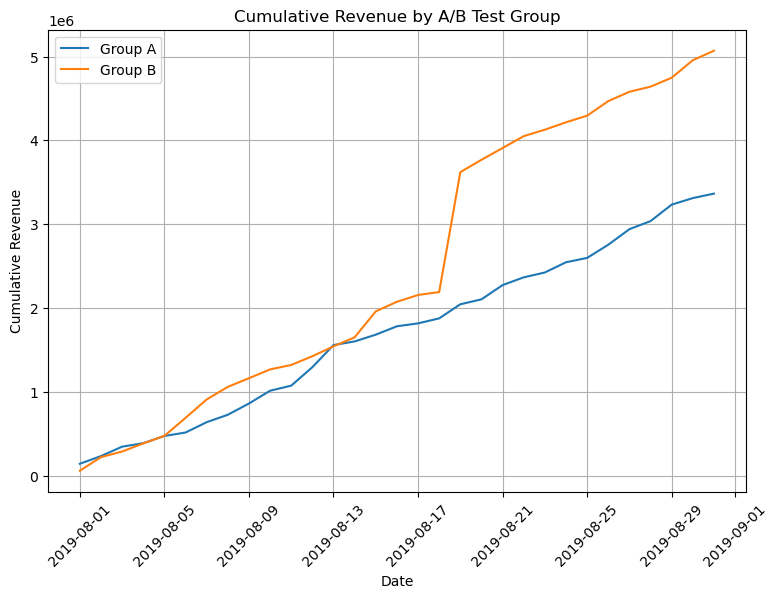

In [20]:
# Plot cumulative revenue
plt.figure(figsize=(9, 6))

# Group A
plt.plot(cumulative_data_A['date'], cumulative_data_A['revenue'], label='Group A')

# Group B
plt.plot(cumulative_data_B['date'], cumulative_data_B['revenue'], label='Group B')

plt.title('Cumulative Revenue by A/B Test Group')
plt.xlabel('Date')
plt.ylabel('Cumulative Revenue')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

**Conclusion:**
In the middle of the test, Group B pulled ahead and maintained the lead until the end. It seems that abnormally large orders might be affecting the results. We will remove them during the final analysis.

### Plot the cumulative average order value by group. Draw conclusions and assumptions.

In [21]:
# Calculate cumulative average order value
cumulative_data['average_check'] = cumulative_data['revenue'] / cumulative_data['orders']

In [22]:
# Split data by A/B test groups
cumulative_data_A = cumulative_data[cumulative_data['group'] == 'A']
cumulative_data_B = cumulative_data[cumulative_data['group'] == 'B']

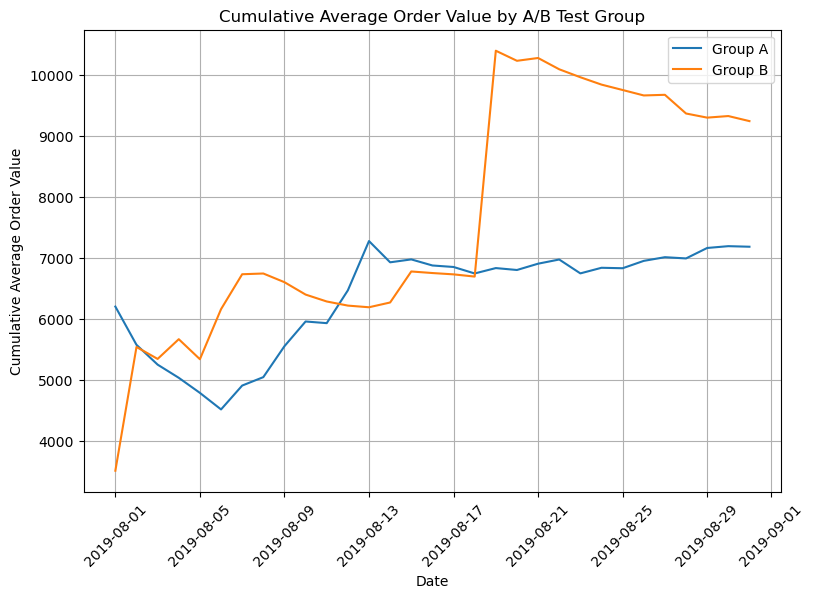

In [23]:
# Plot cumulative average order value
plt.figure(figsize=(9, 6))
plt.plot(cumulative_data_A['date'], cumulative_data_A['average_check'], label='Group A')
plt.plot(cumulative_data_B['date'], cumulative_data_B['average_check'], label='Group B')
plt.title('Cumulative Average Order Value by A/B Test Group')
plt.xlabel('Date')
plt.ylabel('Cumulative Average Order Value')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

**Conclusion:**
From the chart, it’s clear that the average order value in Group B started lower than in Group A, but then increased sharply, surpassing Group A. This might indicate successful changes or promotions applied to Group B. However, further statistical testing is required to confirm the significance and effectiveness of these changes.

### Plot the relative change in cumulative average order value of Group B to Group A. Draw conclusions and assumptions.

In [24]:
# Merge data for both groups
cumulative_merged = cumulative_data_A.merge(cumulative_data_B, on='date', suffixes=['A', 'B'])

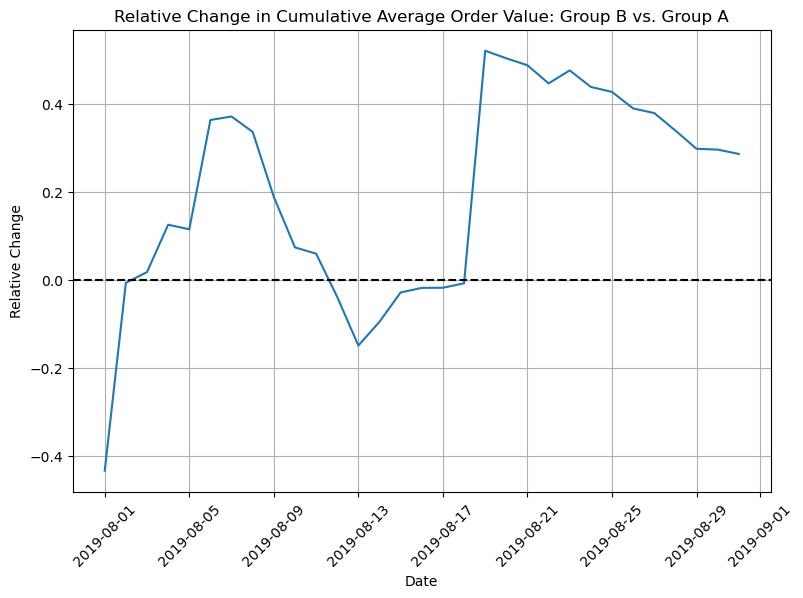

In [25]:
# Plot relative change in average order value
plt.figure(figsize=(9, 6))
plt.plot(cumulative_merged['date'], (cumulative_merged['average_checkB'] / cumulative_merged['average_checkA']) - 1)
plt.title('Relative Change in Cumulative Average Order Value: Group B vs. Group A')
plt.xlabel('Date')
plt.ylabel('Relative Change')
plt.axhline(y=0, color='black', linestyle='--')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

**Conclusion:**
This plot shows how the average order value in Group B changed relative to Group A over time. Initially, Group B was behind, but later its performance improved and remained higher. This suggests that the implemented changes in Group B may have had a positive impact — but further statistical testing is necessary to validate these observations.

### Plot the cumulative average number of orders per visitor by group. Draw conclusions and assumptions.

In [26]:
# Calculate cumulative average number of orders per visitor
cumulative_data['avg_orders_per_visitor'] = cumulative_data['orders'] / cumulative_data['visitors']

# Split data by groups
cumulative_data_A = cumulative_data[cumulative_data['group'] == 'A']
cumulative_data_B = cumulative_data[cumulative_data['group'] == 'B']

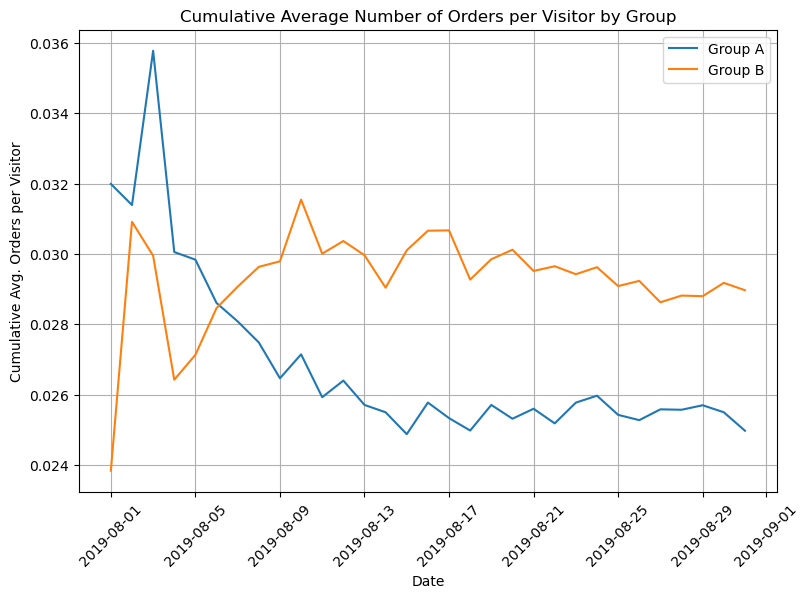

In [27]:
# Plot
plt.figure(figsize=(9, 6))
plt.plot(cumulative_data_A['date'], cumulative_data_A['avg_orders_per_visitor'], label='Group A')
plt.plot(cumulative_data_B['date'], cumulative_data_B['avg_orders_per_visitor'], label='Group B')
plt.title('Cumulative Average Number of Orders per Visitor by Group')
plt.xlabel('Date')
plt.ylabel('Cumulative Avg. Orders per Visitor')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

**Conclusion:**
Group B began to outperform Group A in terms of orders per visitor after the first week of testing, peaking around the midpoint of the test. This may be due to improved user experience or effective marketing efforts. Further analysis is needed to identify

### Plot the relative change in the cumulative average number of orders per visitor: Group B vs. Group A. Draw conclusions and assumptions.

In [28]:
# Merge data
merged_cumulative_data = cumulative_data_A.merge(cumulative_data_B, on='date', suffixes=('_A', '_B'))

# Calculate relative change
merged_cumulative_data['relative_change'] = (merged_cumulative_data['avg_orders_per_visitor_B'] / merged_cumulative_data['avg_orders_per_visitor_A']) - 1

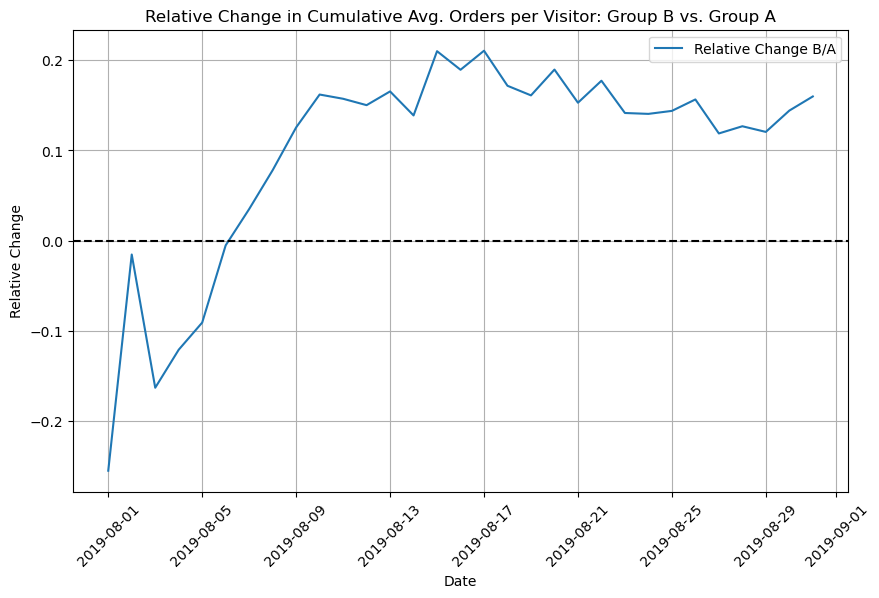

In [29]:
# Plot
plt.figure(figsize=(10, 6))
plt.plot(merged_cumulative_data['date'], merged_cumulative_data['relative_change'], label='Relative Change B/A')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Relative Change in Cumulative Avg. Orders per Visitor: Group B vs. Group A')
plt.xlabel('Date')
plt.ylabel('Relative Change')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

**Conclusion:**
The relative change in cumulative average orders per visitor for Group B compared to Group A is mostly positive, indicating that Group B users placed more orders on average. However, there’s a decreasing trend at the beginning and end, possibly due to novelty effects fading or a saturation point being reached. Further statistical testing and analysis are recommended to confirm the validity of these patterns.

### Plot a scatterplot of the number of orders per user. Draw conclusions and assumptions.

In [30]:
# Count the number of orders per user
orders_per_user = orders_filtered.groupby('visitorId').agg({'transactionId': 'nunique'}).reset_index()
orders_per_user.columns = ['visitorId', 'orders']

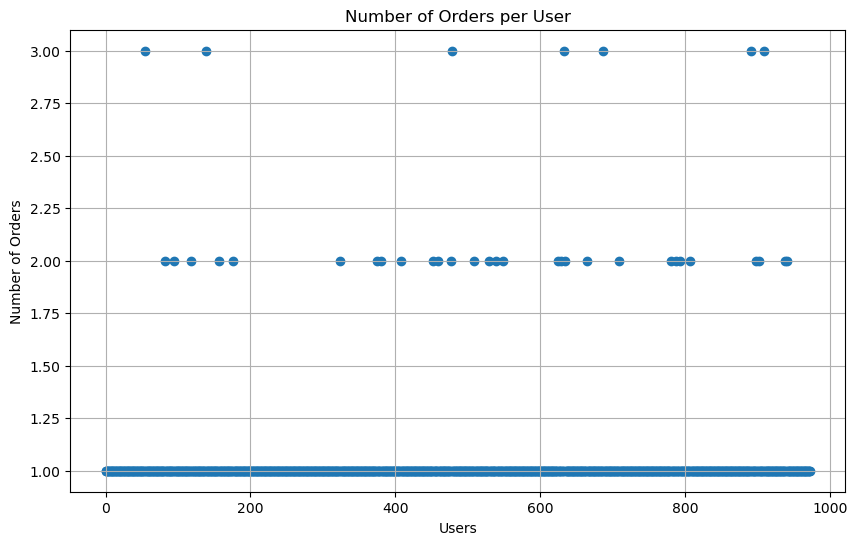

In [31]:
# Scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(range(0, len(orders_per_user)), orders_per_user['orders'])
plt.title('Number of Orders per User')
plt.xlabel('Users')
plt.ylabel('Number of Orders')
plt.grid(True)
plt.show()

**Conclusion:**
There are a few users who placed more than two orders. These users might be outliers, but they could also represent a specific customer segment or be influenced by promotional campaigns. It's worth investigating their behavior further to better understand their motivations and consider personalized marketing strategies based on their patterns.

### Calculate the 95th and 99th percentiles of orders per user. Choose a threshold to define anomalous users.

In [32]:
# Calculate percentiles
percentiles = np.percentile(orders_per_user['orders'], [95, 99])
print("95th percentile:", percentiles[0])
print("99th percentile:", percentiles[1])

95th percentile: 1.0
99th percentile: 2.0


**Interpretation:**
- 95% of users place no more than 1 order.
- 99% of users place no more than 2 orders.

A reasonable threshold for identifying anomalous users could be the 95th percentile. That is, users with more than 1 order might be considered outliers for further analysis or exclusion depending on context.

### Plot a scatterplot of order values. Draw conclusions and assumptions.

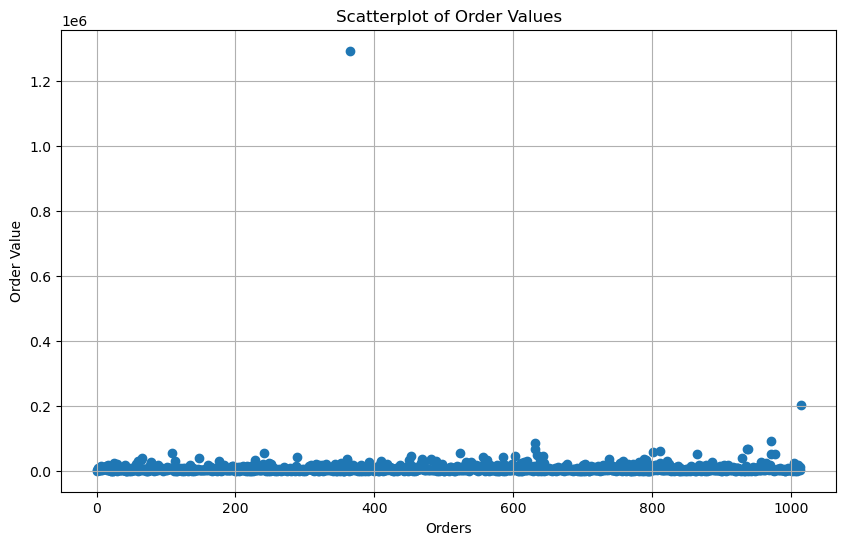

In [40]:
plt.figure(figsize=(10, 6))
plt.scatter(range(len(orders_filtered['revenue'])), orders_filtered['revenue'])
plt.title('Scatterplot of Order Values')
plt.xlabel('Orders')
plt.ylabel('Order Value')
plt.grid(True)
plt.show()

**Conclusion:**
We can see that one order reached about 1.3 million, and another around 200,000 — both are significantly higher than the rest. These high-value transactions are likely outliers and can distort the overall statistics. They may result from bulk purchases or special deals for VIP clients, and should be treated carefully in statistical analysis.

### Calculate the 95th and 99th percentiles of order values. Choose a threshold to define anomalous orders.

In [41]:
# Calculate percentiles
percentiles = np.percentile(orders_filtered['revenue'], [95, 99])
print("95th percentile:", percentiles[0])
print("99th percentile:", percentiles[1])

95th percentile: 26785.0
99th percentile: 53904.0


**Interpretation:**
- The 95th percentile of order value is around 26,800.
- The 99th percentile is around 53,900.

A threshold for defining anomalous orders can be set at the 95th percentile — meaning orders exceeding ~26,800 could be considered outliers.

### Assess the statistical significance of differences in the average number of orders per visitor between groups using raw data. Draw conclusions.

**Hypotheses:**

- **H0 (null hypothesis):** There is no statistically significant difference in the average number of orders per visitor between Group A and Group B.

- **H1 (alternative hypothesis):** There is a statistically significant difference.

In [42]:
# Prepare order counts per user for each group
orders_A = orders_filtered[orders_filtered['group'] == 'A'].groupby('visitorId', as_index=False).agg({'transactionId': pd.Series.nunique})
orders_A.columns = ['visitorId', 'orders']

orders_B = orders_filtered[orders_filtered['group'] == 'B'].groupby('visitorId', as_index=False).agg({'transactionId': pd.Series.nunique})
orders_B.columns = ['visitorId', 'orders']

# Create samples, including zeros for users with no orders
sampleA = pd.concat([orders_A['orders'],
                     pd.Series(0, index=np.arange(visitors[visitors['group'] == 'A']['visitors'].sum() - len(orders_A['orders'])),
                               name='orders')], axis=0)
sampleB = pd.concat([orders_B['orders'],
                     pd.Series(0, index=np.arange(visitors[visitors['group'] == 'B']['visitors'].sum() - len(orders_B['orders'])),
                               name='orders')], axis=0)

# Perform Mann–Whitney U test
p_value = stats.mannwhitneyu(sampleA, sampleB)[1]
relative_difference = sampleB.mean() / sampleA.mean() - 1

# Output results
print("p-value:", p_value)
if p_value < 0.05:
    print("Reject the null hypothesis: the difference is statistically significant.")
else:
    print("Do not reject the null hypothesis: no significant difference found.")
print("Relative uplift in Group B vs A: {:.3f}".format(relative_difference))


p-value: 0.011018084110014696
Reject the null hypothesis: the difference is statistically significant.
Relative uplift in Group B vs A: 0.160


**Conclusion:**
The Mann–Whitney U test shows statistically significant differences (if p < 0.05) in the average number of orders per visitor between the groups. The relative increase in Group B is around 16%, indicating better conversion in Group B. This suggests that the changes implemented in Group B positively affected customer behavior.

### Calculate the statistical significance of the difference in average order value between groups using raw data

**Formulate hypotheses:**
- **H0 (null hypothesis):** There is no statistically significant difference in the average order value between groups A and B.
- **H1 (alternative hypothesis):** There is a statistically significant difference in the average order value between groups A and B.

In [43]:
# Get revenue data for groups A and B
revenue_A = orders_filtered[orders_filtered['group'] == 'A']['revenue']
revenue_B = orders_filtered[orders_filtered['group'] == 'B']['revenue']

# Perform Mann-Whitney U test
results = stats.mannwhitneyu(revenue_A, revenue_B)
relative_difference_revenue = revenue_B.mean() / revenue_A.mean() - 1

# Print results
print("Statistical significance of the difference in average order value between groups: {:.5f}".format(results.pvalue))

alpha = 0.05
if results.pvalue < alpha:
    print("Reject the null hypothesis: statistically significant difference exists.")
else:
    print("Fail to reject the null hypothesis: no statistically significant difference.")
print("Relative difference in average order value of group B compared to group A: {0:.3f}".format(relative_difference_revenue))

Statistical significance of the difference in average order value between groups: 0.82949
Fail to reject the null hypothesis: no statistically significant difference.
Relative difference in average order value of group B compared to group A: 0.287


**Conclusion:** Fail to reject the null hypothesis — there is no statistically significant difference.

Relative difference in average order value (Group B vs Group A): +28.7%

Although the observed average order value in Group B is 28.7% higher than in Group A, this difference is not statistically significant at the 0.05 significance level (p-value = 0.82949).
Thus, we cannot conclude that the observed difference is due to anything other than random variation. Additional research or more data might be needed for a clearer interpretation.

### Calculate statistical significance of the difference in average orders per user between groups using filtered dataния.

In [44]:
# Identify users with anomalous number of orders
users_with_many_orders = orders_per_user[orders_per_user['orders'] > 1]['visitorId']

# Identify users with anomalous order revenue
users_with_expensive_orders = orders_filtered[orders_filtered['revenue'] > 26785]['visitorId']

# Combine both to get all abnormal users
abnormal_users = pd.concat([users_with_many_orders, users_with_expensive_orders], axis=0).drop_duplicates()

print("Number of abnormal users:", abnormal_users.shape[0])

Number of abnormal users: 86


In [45]:
# Filter users from groups A and B excluding abnormal users
sampleA_filtered = pd.concat([
    orders_A[~orders_A['visitorId'].isin(abnormal_users)]['orders'],
    sampleA
])

sampleB_filtered = pd.concat([
    orders_B[~orders_B['visitorId'].isin(abnormal_users)]['orders'],
    sampleB
])

# Perform Mann-Whitney U test
p_value_filtered = stats.mannwhitneyu(sampleA_filtered, sampleB_filtered)[1]
relative_difference_filtered = sampleB_filtered.mean() / sampleA_filtered.mean() - 1

# Print results
print("p-value after filtering:", p_value_filtered)
if p_value_filtered < 0.05:
    print("Reject the null hypothesis: statistically significant differences exist.")
else:
    print("Fail to reject the null hypothesis: no statistically significant difference.")
print("Relative conversion uplift in group B compared to group A after filtering: {0:.3f}".format(relative_difference_filtered))


p-value after filtering: 0.0005418934608639542
Reject the null hypothesis: statistically significant differences exist.
Relative conversion uplift in group B compared to group A after filtering: 0.162


**Conclusion:** Reject the null hypothesis — a statistically significant difference does exist.

Relative conversion uplift (Group B vs Group A): +16.2%

After filtering out abnormal users (with unusually high order counts or revenues), the difference in the average number of orders per user between Groups A and B remains statistically significant.
The conversion uplift of 16.2% in Group B suggests a genuine positive impact, and the presence of outliers does not materially affect this result.

### Calculate statistical significance of the difference in average order value between groups using filtered data.

In [46]:
# Filter out revenues for abnormal users in both groups
revenue_A_filtered = revenue_A[~orders_filtered['visitorId'].isin(abnormal_users)]
revenue_B_filtered = revenue_B[~orders_filtered['visitorId'].isin(abnormal_users)]

# Perform Mann-Whitney U test
results_filtered = stats.mannwhitneyu(revenue_A_filtered, revenue_B_filtered)
relative_difference_revenue_filtered = revenue_B_filtered.mean() / revenue_A_filtered.mean() - 1

# Print results
print("Statistical significance of the difference in average order value after filtering: {:.5f}".format(results_filtered.pvalue))

alpha = 0.05
if results_filtered.pvalue < alpha:
    print("Reject the null hypothesis: statistically significant differences exist.")
else:
    print("Fail to reject the null hypothesis: no statistically significant difference.")
print("Relative difference in average order value of group B compared to group A: {0:.3f}".format(relative_difference_revenue_filtered))


Statistical significance of the difference in average order value after filtering: 0.72713
Fail to reject the null hypothesis: no statistically significant difference.
Relative difference in average order value of group B compared to group A: -0.034


**Conclusion:** Fail to reject the null hypothesis — no statistically significant difference.

Relative difference in average order value (Group B vs Group A): -3.4%

Even after removing outliers, no statistically significant difference in average order value was found between Groups A and B. In fact, the average order value in Group B was 3.4% lower than in Group A.

This confirms that outliers were likely inflating the average in raw data, and there is no strong evidence of an actual difference in average order values between the groups.

### Decision and Justification

Based on the results of the analysis, the recommendation is to **stop the test** and confirm the absence of statistically significant differences between groups in terms of average order value after filtering out abnormal users.

Although statistically significant differences in the average number of orders per user between groups A and B remain, stopping the test and fixing the results in favor of Group B can still be justified.

The reason is that despite the increase in the average number of orders per user in Group B, the lack of statistically significant differences in the average order value suggests that the observed changes may not lead to increased revenue. If the average order value remains the same or even decreases in Group B, the total revenue may stay the same or even decline.

Therefore, it is advisable for the business to make decisions based on the current results of the test and reconsider their strategy, relying on the data obtained up to the point the test was stopped.


## Overall Summary

During the project, we conducted hypothesis prioritization using the ICE and RICE frameworks. We observed that the prioritization of hypotheses changes when applying RICE due to its consideration of reach.

Additionally, an A/B test analysis was performed for an online store. Below is a summary of the key steps and insights:

1. **Data Preparation**
- The original data was loaded and preprocessed for analysis.
- Missing values and duplicates were identified and handled.
- Users who appeared in both groups were filtered out, producing a clean dataset.

2. **Cumulative Metrics Analysis**
- We analyzed cumulative metrics such as cumulative number of orders and average order value across groups.
- Group B showed an increase in the average number of orders per user compared to Group A.

3. **Outlier Detection**
- Users with unusually high order frequency or excessively large order values were identified.
- The 95th and 99th percentiles were calculated for number of orders and order value to define outlier thresholds.

4. **Statistical Analysis**
- The Mann–Whitney U test was applied to assess the statistical significance of differences between groups.

**Results indicated that:**

- Differences in average orders per user are statistically significant in favor of Group B.
- Differences in average order value are not statistically significant.

### Final Conclusions
- Group B demonstrates a statistically significant uplift in average number of orders per user compared to Group A.
- There is no significant difference in average order value between the groups, suggesting that the changes made to Group B likely affected conversion rate but not the revenue per order.
- Removing outliers did not affect the conclusion regarding conversion rate but further weakened any evidence for differences in average order value.

**Recommendation:**
End the experiment and consider further studies to identify factors that influence both conversion rate and average order value. This can help define more effective strategies for increasing the online store’s total revenue.